In [ ]:
import sys
print(sys.version)


3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
!pip install --upgrade pip

!pip install gymnasium>=1.0.0
!pip install ale-py>=0.11.0
!pip install gymnasium[atari]
!pip install autorom
!pip install numpy matplotlib opencv-python torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
!AutoROM --accept-license


AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


In [ ]:
import ale_py
import gymnasium as gym
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

# THIS IS THE MISSING STEP
gym.register_envs(ale_py)

env = gym.make(
    "ALE/Breakout-v5",
    render_mode=None,
    frameskip=1
)

env = AtariPreprocessing(
    env,
    grayscale_obs=True,
    scale_obs=False,
    frame_skip=4
)

env = FrameStackObservation(env, stack_size=4)

obs, info = env.reset()
print("Observation shape:", obs.shape)

env.close()


Observation shape: (4, 84, 84)


DQN baseline

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import deque
import random


In [ ]:
# Environment details
STATE_SHAPE = (4, 84, 84)
NUM_ACTIONS = 4   # Breakout actions

# DQN hyperparameters (Nature DQN style)
GAMMA = 0.99
LR = 1e-4
BATCH_SIZE = 32
REPLAY_BUFFER_SIZE = 50_000
MIN_REPLAY_SIZE = 5_000

TARGET_UPDATE_FREQ = 10_000   # steps
EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY_STEPS = 1_000_000

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [ ]:
class DQN(nn.Module):
    def __init__(self, num_actions):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(7 * 7 * 64, 512),
            nn.ReLU(),
            nn.Linear(512, num_actions)
        )

    def forward(self, x):
        x = x / 255.0          # normalize pixel values
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [ ]:
model = DQN(NUM_ACTIONS).to(DEVICE)
dummy = torch.zeros((1, *STATE_SHAPE)).to(DEVICE)
print("Q-values shape:", model(dummy).shape)


Q-values shape: torch.Size([1, 4])


replay buffer

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32).to(DEVICE)
        actions = torch.tensor(actions, dtype=torch.long).to(DEVICE)
        rewards = torch.tensor(rewards, dtype=torch.float32).to(DEVICE)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32).to(DEVICE)
        dones = torch.tensor(dones, dtype=torch.float32).to(DEVICE)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


In [ ]:
replay_buffer = ReplayBuffer(REPLAY_BUFFER_SIZE)
print("Replay buffer created")


Replay buffer created


In [ ]:
# Create fake data to test
fake_state = np.zeros(STATE_SHAPE, dtype=np.uint8)
fake_next_state = np.ones(STATE_SHAPE, dtype=np.uint8)

replay_buffer.add(fake_state, 1, 1.0, fake_next_state, False)

sample = replay_buffer.sample(1)
print("Sampled states shape:", sample[0].shape)
print("Sampled actions:", sample[1])



Sampled states shape: torch.Size([1, 4, 84, 84])
Sampled actions: tensor([1], device='cuda:0')


Target Network + ε-Greedy Action Selection

In [ ]:
# Online (policy) network
policy_net = DQN(NUM_ACTIONS).to(DEVICE)

# Target network
target_net = DQN(NUM_ACTIONS).to(DEVICE)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()   # target net is not trained directly

print("Policy & Target networks initialized")


Policy & Target networks initialized


In [ ]:
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
loss_fn = nn.SmoothL1Loss()   # Huber loss (used in Atari DQN)

print("Optimizer and loss function ready")


Optimizer and loss function ready


In [ ]:
def select_action(state, step):
    """
    state: numpy array (4, 84, 84)
    step: global training step
    """
    epsilon = max(
        EPSILON_END,
        EPSILON_START - step / EPSILON_DECAY_STEPS
    )

    if random.random() < epsilon:
        return random.randrange(NUM_ACTIONS)
    else:
        state_tensor = torch.tensor(
            state, dtype=torch.float32
        ).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            q_values = policy_net(state_tensor)

        return q_values.argmax(dim=1).item()


In [ ]:
def update_target_network():
    target_net.load_state_dict(policy_net.state_dict())


In [ ]:
dummy_state = np.zeros(STATE_SHAPE, dtype=np.uint8)

for step in [0, 500_000, 1_000_000]:
    action = select_action(dummy_state, step)
    print(f"Step {step}, selected action:", action)


Step 0, selected action: 3
Step 500000, selected action: 3
Step 1000000, selected action: 0


DQN TRAINING STEP (Bellman Update)

In [ ]:
def train_step():
    # Do not train until replay buffer has enough samples
    if len(replay_buffer) < MIN_REPLAY_SIZE:
        return None

    # Sample a batch
    states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

    # Current Q-values for taken actions
    q_values = policy_net(states)
    q_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

    # Target Q-values (no gradient)
    with torch.no_grad():
        next_q_values = target_net(next_states)
        max_next_q_values = next_q_values.max(dim=1)[0]
        target_q_values = rewards + GAMMA * max_next_q_values * (1 - dones)

    # Loss
    loss = loss_fn(q_values, target_q_values)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [ ]:
# Fill replay buffer with fake data for testing
for _ in range(MIN_REPLAY_SIZE):
    s = np.zeros(STATE_SHAPE, dtype=np.uint8)
    ns = np.zeros(STATE_SHAPE, dtype=np.uint8)
    replay_buffer.add(s, random.randint(0, 3), 0.0, ns, False)

loss = train_step()
print("Training step loss:", loss)


Training step loss: 7.418010500259697e-05


In [ ]:
import os
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation, RecordVideo

# Register ALE (safe to run multiple times)
gym.register_envs(ale_py)

VIDEO_DIR = "./videos"
os.makedirs(VIDEO_DIR, exist_ok=True)

def make_env(record=False):
    env = gym.make(
        "ALE/Breakout-v5",
        render_mode="rgb_array" if record else None,
        frameskip=1
    )

    env = AtariPreprocessing(
        env,
        grayscale_obs=True,
        scale_obs=False,
        frame_skip=4
    )

    env = FrameStackObservation(env, stack_size=4)

    if record:
        env = RecordVideo(
            env,
            video_folder=VIDEO_DIR,
            episode_trigger=lambda e: True
        )

    return env


In [ ]:
env = make_env(record=False)

num_steps = 200_000   # start small (increase later)
episode_reward = 0
state, info = env.reset()

from collections import deque
rewards_history = deque(maxlen=1000)


for step in range(num_steps):

    action = select_action(state, step)
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    replay_buffer.add(state, action, reward, next_state, done)
    state = next_state
    episode_reward += reward

    loss = train_step()

    if step % TARGET_UPDATE_FREQ == 0:
        update_target_network()

    if done:
        rewards_history.append(episode_reward)
        episode_reward = 0
        state, info = env.reset()

    if step % 5_000 == 0 and step > 0:
        print(f"Step {step}, Episodes {len(rewards_history)}")

env.close()


Step 5000, Episodes 25
Step 10000, Episodes 48
Step 15000, Episodes 76
Step 20000, Episodes 99
Step 25000, Episodes 124
Step 30000, Episodes 151
Step 35000, Episodes 178
Step 40000, Episodes 202
Step 45000, Episodes 227
Step 50000, Episodes 253
Step 55000, Episodes 279
Step 60000, Episodes 307
Step 65000, Episodes 334
Step 70000, Episodes 362
Step 75000, Episodes 390
Step 80000, Episodes 417
Step 85000, Episodes 445
Step 90000, Episodes 469
Step 95000, Episodes 494
Step 100000, Episodes 522
Step 105000, Episodes 550
Step 110000, Episodes 575
Step 115000, Episodes 604
Step 120000, Episodes 632
Step 125000, Episodes 654
Step 130000, Episodes 680
Step 135000, Episodes 708
Step 140000, Episodes 733
Step 145000, Episodes 759
Step 150000, Episodes 784
Step 155000, Episodes 810
Step 160000, Episodes 835
Step 165000, Episodes 863
Step 170000, Episodes 892
Step 175000, Episodes 916
Step 180000, Episodes 942
Step 185000, Episodes 967
Step 190000, Episodes 995
Step 195000, Episodes 1000


In [ ]:
torch.save(policy_net.state_dict(), "dqn_breakout_final.pth")
print("Final model saved")


Final model saved


In [ ]:
from google.colab import files
files.download("dqn_breakout_final.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

run this so that no need to re-train the model

In [ ]:
policy_net.load_state_dict(
    torch.load("dqn_breakout_final.pth", map_location=DEVICE)
)
policy_net.eval()


DQN(
  (conv): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=4, bias=True)
  )
)

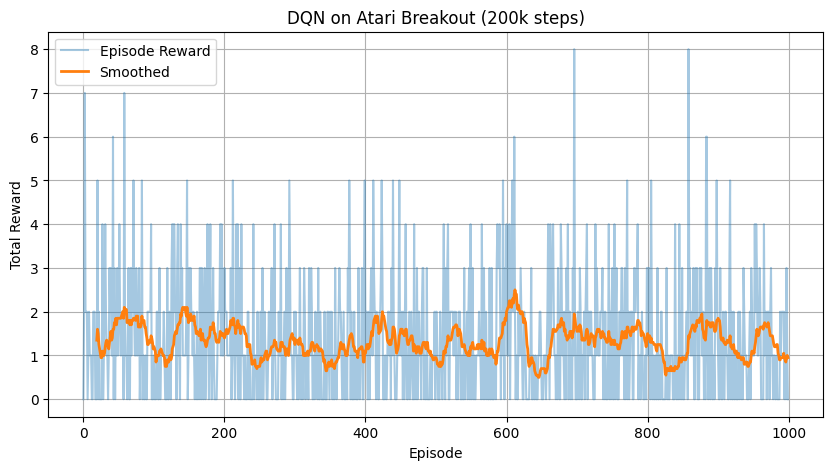

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rewards = np.array(list(rewards_history))

plt.figure(figsize=(10,5))
plt.plot(rewards, alpha=0.4, label="Episode Reward")

smooth = np.convolve(rewards, np.ones(20)/20, mode="valid")
plt.plot(range(19, 19+len(smooth)), smooth, linewidth=2, label="Smoothed")

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN on Atari Breakout (200k steps)")
plt.legend()
plt.grid()
plt.show()


recording environment

In [ ]:
# 1. Load trained model
policy_net.load_state_dict(
    torch.load("dqn_breakout_final.pth", map_location=DEVICE)
)
policy_net.eval()

# 2. Create evaluation environment WITH recording
eval_env = make_env(record=True)

state, info = eval_env.reset()
done = False
total_reward = 0

while not done:
    with torch.no_grad():
        state_tensor = torch.tensor(
            state, dtype=torch.float32
        ).unsqueeze(0).to(DEVICE)

        action = policy_net(state_tensor).argmax(dim=1).item()

    state, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated
    total_reward += reward

eval_env.close()
print("Evaluation episode reward:", total_reward)


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Evaluation episode reward: 3.0


In [ ]:
from google.colab import files

files.download("videos/rl-video-episode-0.mp4")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import random

# Load trained model
policy_net.load_state_dict(
    torch.load("dqn_breakout_final.pth", map_location=DEVICE)
)
policy_net.eval()

TOTAL_EVAL_EPISODES = 11
NUM_RANDOM_VIDEOS = 4

# Randomly choose which evaluation episodes to record
record_eps = set(random.sample(range(TOTAL_EVAL_EPISODES), NUM_RANDOM_VIDEOS))
print("Recording evaluation episodes:", record_eps)

eval_env = make_env(record=True)

for ep in range(TOTAL_EVAL_EPISODES):
    state, info = eval_env.reset()
    done = False
    total_reward = 0

    while not done:
        with torch.no_grad():
            state_tensor = torch.tensor(
                state, dtype=torch.float32
            ).unsqueeze(0).to(DEVICE)

            action = policy_net(state_tensor).argmax(dim=1).item()

        state, reward, terminated, truncated, info = eval_env.step(action)
        done = terminated or truncated
        total_reward += reward

    print(f"Evaluation episode {ep} finished | Reward = {total_reward}")

eval_env.close()


Recording evaluation episodes: {0, 17, 11, 12}


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Evaluation episode 0 finished | Reward = 3.0
Evaluation episode 1 finished | Reward = 1.0
Evaluation episode 2 finished | Reward = 1.0
Evaluation episode 3 finished | Reward = 2.0
Evaluation episode 4 finished | Reward = 2.0
Evaluation episode 5 finished | Reward = 5.0
Evaluation episode 6 finished | Reward = 3.0
Evaluation episode 7 finished | Reward = 3.0
Evaluation episode 8 finished | Reward = 2.0
Evaluation episode 9 finished | Reward = 2.0
Evaluation episode 10 finished | Reward = 3.0
Evaluation episode 11 finished | Reward = 2.0
Evaluation episode 12 finished | Reward = 2.0
Evaluation episode 13 finished | Reward = 1.0
Evaluation episode 14 finished | Reward = 1.0
Evaluation episode 15 finished | Reward = 3.0
Evaluation episode 16 finished | Reward = 3.0
Evaluation episode 17 finished | Reward = 2.0
Evaluation episode 18 finished | Reward = 4.0
Evaluation episode 19 finished | Reward = 3.0


KeyboardInterrupt: 

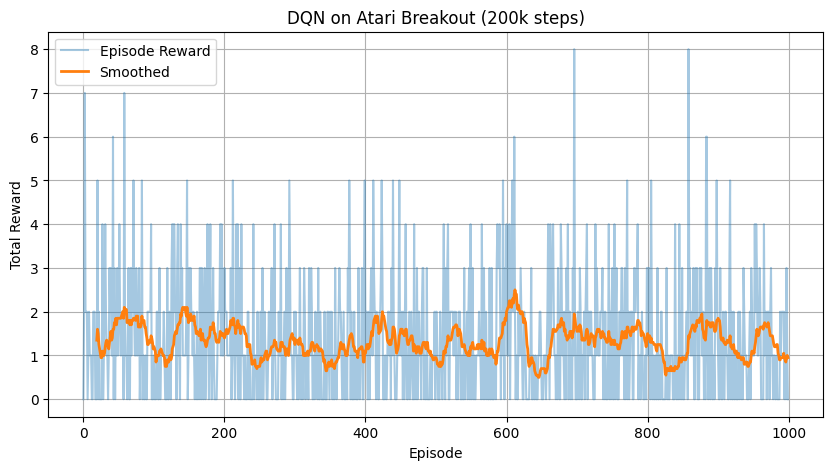

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rewards = list(rewards_history)

# Moving average (smooth curve)
window = 20
smoothed = np.convolve(
    rewards, np.ones(window)/window, mode="valid"
)

plt.figure(figsize=(10, 5))
plt.plot(rewards, alpha=0.4, label="Episode Reward")
plt.plot(
    range(window - 1, len(rewards)),
    smoothed,
    linewidth=2,
    label="Smoothed"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN on Atari Breakout (200k steps)")
plt.legend()
plt.grid(True)

#  THIS IS THE KEY LINE
plt.savefig("dqn_breakout_reward_plot.png", dpi=300, bbox_inches="tight")

plt.show()


last-step for dqn

In [ ]:
import shutil

shutil.make_archive("videos", "zip", "videos")
from google.colab import files
files.download("videos.zip")
